In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the spotify cleaned data
df = pd.read_csv('spotify_cleaned.csv')

In [23]:
## Dataset Overview
# Display first few rows
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Show data types
print("\n" + "="*60)
print("Data Types:")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("Column Information by Type:")
print("="*60)

# Categorize columns by type
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Boolean columns ({len(bool_cols)}): {bool_cols}")
if datetime_cols:
    print(f"DateTime columns ({len(datetime_cols)}): {datetime_cols}")

Dataset shape: (84979, 22)

First few rows:
           track_id              track_name    artist_name         album_name  \
0  TRK-BEBD53DA84E1         Agent every (0)    Noah Rhodes  Beautiful instead   
1  TRK-6A32496762D7           Night respond  Jennifer Cole              Table   
2  TRK-47AA7523463E  Future choice whatever  Brandon Davis      Page southern   
3  TRK-25ADA22E3B06     Bad fall pick those    Corey Jones             Spring   
4  TRK-9245F2AD996A                 Husband      Mark Diaz        Great prove   

  release_date  genre  duration_ms  popularity  danceability  energy  ...  \
0   2016-04-01    Pop       234194          55          0.15    0.74  ...   
1   2022-04-15  Metal       375706          45          0.44    0.46  ...   
2   2016-02-23   Rock       289191          55          0.62    0.80  ...   
3   2015-10-12    Pop       209484          51          0.78    0.98  ...   
4   2022-07-08  Indie       127435          39          0.74    0.18  ...   

   mod


Correlation Matrix:
                  duration_ms  popularity  danceability    energy       key  \
duration_ms          1.000000   -0.000627     -0.005206 -0.003981 -0.003530   
popularity          -0.000627    1.000000      0.003170 -0.000367 -0.003207   
danceability        -0.005206    0.003170      1.000000 -0.004068 -0.002814   
energy              -0.003981   -0.000367     -0.004068  1.000000  0.004509   
key                 -0.003530   -0.003207     -0.002814  0.004509  1.000000   
loudness             0.001995    0.003244      0.002440  0.005547  0.005627   
mode                -0.001842   -0.001620      0.000114 -0.003767 -0.003137   
instrumentalness    -0.004069    0.002308      0.004491  0.002290  0.000469   
tempo               -0.001542   -0.002757     -0.002539 -0.006587  0.002405   
stream_count         0.000506    0.357539      0.000452 -0.001401 -0.001014   
explicit            -0.003812   -0.000893      0.001590  0.001574 -0.002151   
duration_sec         1.000000  

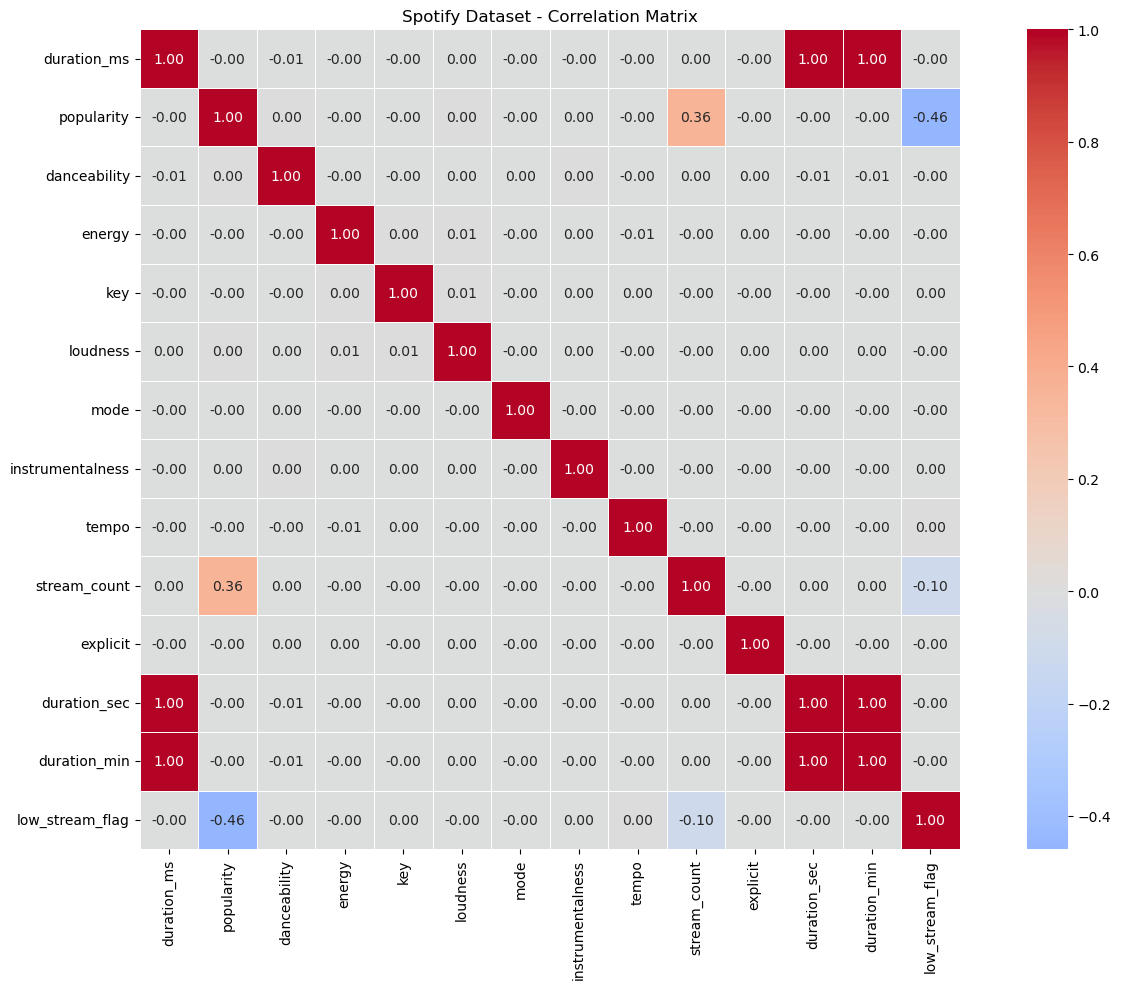

In [24]:
## 1) Correlation Matrix 
# Create correlation matrix (only for numeric columns)
correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Spotify Dataset - Correlation Matrix')
plt.tight_layout()
plt.show()

INTERACTION TERMS ANALYSIS (Refined Features)
Testing which interaction terms are significant for A/B testing

Correlation Matrix (Refined Features):
                  popularity  danceability  energy    key  loudness   mode  \
popularity             1.000         0.003  -0.000 -0.003     0.003 -0.002   
danceability           0.003         1.000  -0.004 -0.003     0.002  0.000   
energy                -0.000        -0.004   1.000  0.005     0.006 -0.004   
key                   -0.003        -0.003   0.005  1.000     0.006 -0.003   
loudness               0.003         0.002   0.006  0.006     1.000 -0.004   
mode                  -0.002         0.000  -0.004 -0.003    -0.004  1.000   
instrumentalness       0.002         0.004   0.002  0.000     0.002 -0.002   
tempo                 -0.003        -0.003  -0.007  0.002    -0.001 -0.004   
stream_count           0.358         0.000  -0.001 -0.001    -0.002 -0.001   
duration_min          -0.001        -0.005  -0.004 -0.004     0.002 -0

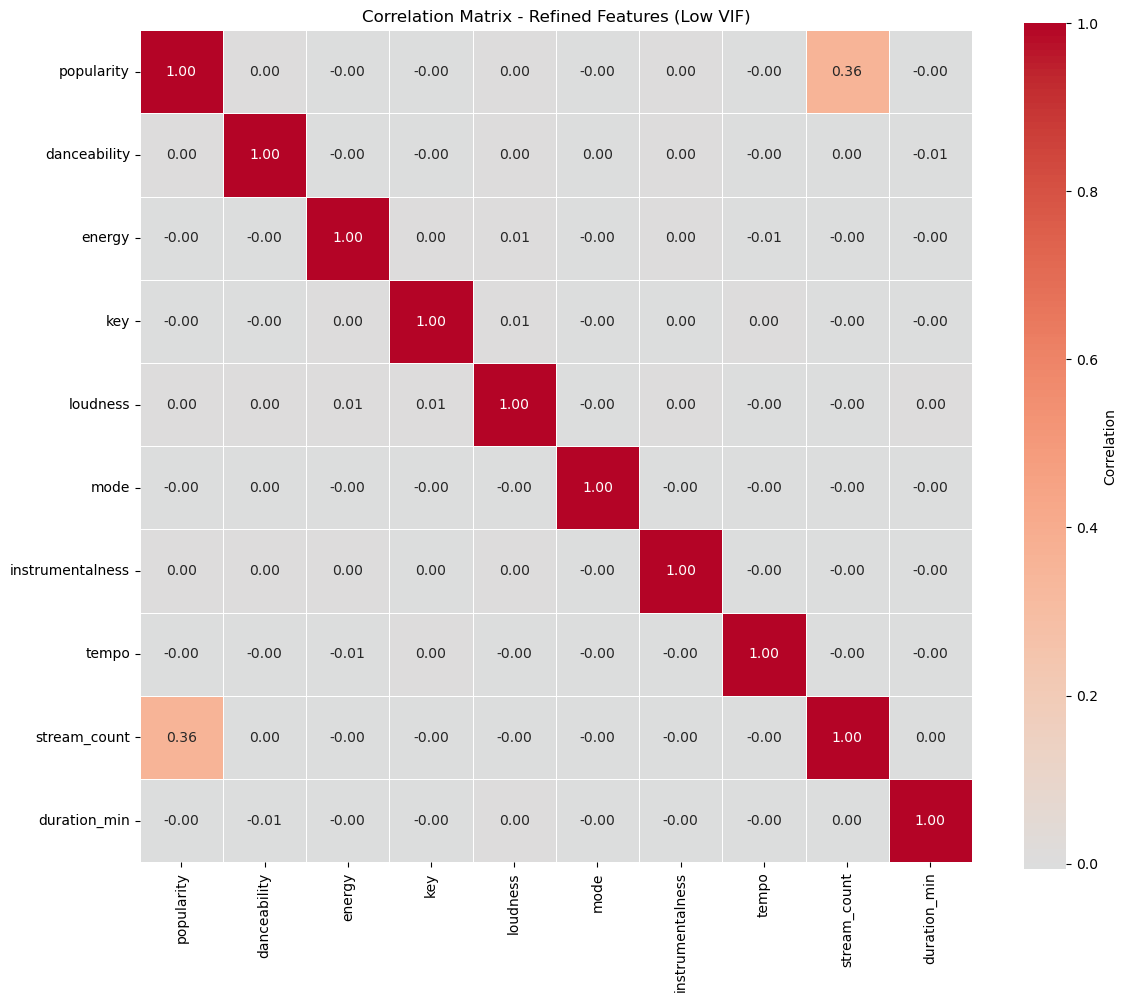


RECOMMENDED METRICS FOR A/B TESTING
Features (low multicollinearity, VIF < 10):
  1. popularity           (VIF:   1.15)
  2. danceability         (VIF:   1.00)
  3. energy               (VIF:   1.00)
  4. key                  (VIF:   1.00)
  5. loudness             (VIF:   1.00)
  6. mode                 (VIF:   1.00)
  7. instrumentalness     (VIF:   1.00)
  8. tempo                (VIF:   1.00)
  9. stream_count         (VIF:   1.15)
  10. duration_min         (VIF:   1.00)


In [25]:
## 2.5) Interaction Terms Analysis on Refined Features
print("="*80)
print("INTERACTION TERMS ANALYSIS (Refined Features)")
print("="*80)
print("Testing which interaction terms are significant for A/B testing\n")

# Get refined features
refined_features = list(X_refined.columns)

# Show correlation matrix for refined features
correlation_refined = df_refined[refined_features].corr()

print("Correlation Matrix (Refined Features):")
print(correlation_refined.round(3))

# Find high correlations (excluding diagonal)
print("\n" + "-"*80)
print("High Correlations (|r| > 0.7) Among Refined Features:")
print("-"*80)

high_corr_pairs = []
for i in range(len(correlation_refined.columns)):
    for j in range(i+1, len(correlation_refined.columns)):
        corr_val = correlation_refined.iloc[i, j]
        if abs(corr_val) > 0.7:
            feat1 = correlation_refined.columns[i]
            feat2 = correlation_refined.columns[j]
            high_corr_pairs.append((feat1, feat2, corr_val))
            print(f"  {feat1} ↔ {feat2}: {corr_val:.3f}")

if not high_corr_pairs:
    print("  ✓ No high correlations (>0.7) found among refined features")

# Visualize correlation matrix for refined features
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_refined, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Refined Features (Low VIF)')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("RECOMMENDED METRICS FOR A/B TESTING")
print("="*80)
print(f"Features (low multicollinearity, VIF < 10):")
for i, feat in enumerate(refined_features, 1):
    vif_val = vif_final[vif_final['Feature'] == feat]['VIF'].values[0]
    print(f"  {i}. {feat:20s} (VIF: {vif_val:6.2f})")


In [26]:
## 2) VIF Analysis - Multicollinearity Testing for Feature Selection
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("="*80)
print("VIF measures how much the variance of a coefficient is inflated due to multicollinearity")
print("VIF > 10: High multicollinearity (drop feature)")
print("VIF 5-10: Moderate multicollinearity (consider dropping)")
print("VIF < 5: Acceptable level\n")

# Get numeric columns
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

# Standardize features for VIF calculation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols_all])
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols_all)

# Calculate VIF for all features
print("INITIAL VIF ANALYSIS (All Features)")
print("-" * 80)
vif_results = pd.DataFrame()
vif_results['Feature'] = numeric_cols_all
vif_results['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
vif_results = vif_results.sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_results.to_string(index=False))

# Categorize features by VIF level
high_vif = vif_results[vif_results['VIF'] > 10]['Feature'].tolist()
moderate_vif = vif_results[(vif_results['VIF'] >= 5) & (vif_results['VIF'] <= 10)]['Feature'].tolist()
acceptable_vif = vif_results[vif_results['VIF'] < 5]['Feature'].tolist()

print(f"\n✓ Acceptable VIF (< 5): {len(acceptable_vif)} features")
print(f"   {acceptable_vif[:5]}{'...' if len(acceptable_vif) > 5 else ''}")

if moderate_vif:
    print(f"\n⚠️  Moderate multicollinearity (5-10): {len(moderate_vif)} features")
    print(f"   {moderate_vif}")

if high_vif:
    print(f"\n❌ High multicollinearity (> 10): {len(high_vif)} features")
    print(f"   {high_vif}")

# Iterative VIF reduction - drop highest VIF features one by one
print("\n" + "="*80)
print("ITERATIVE VIF REDUCTION")
print("="*80)
print("Dropping features with VIF > 10 iteratively until all remaining VIF < 10\n")

X_refined = X_scaled_df.copy()
dropped_features = []
iteration = 0

while True:
    iteration += 1
    vif_current = pd.DataFrame()
    vif_current['Feature'] = X_refined.columns
    vif_current['VIF'] = [variance_inflation_factor(X_refined.values, i) for i in range(X_refined.shape[1])]
    vif_current = vif_current.sort_values('VIF', ascending=False)
    
    max_vif = vif_current['VIF'].max()
    
    if max_vif > 10:
        feature_to_drop = vif_current.iloc[0]['Feature']
        drop_vif = vif_current.iloc[0]['VIF']
        print(f"Iteration {iteration}: Dropping '{feature_to_drop}' (VIF = {drop_vif:.2f})")
        X_refined = X_refined.drop(columns=[feature_to_drop])
        dropped_features.append(feature_to_drop)
    else:
        print(f"\n✓ Completed after {iteration-1} iterations")
        break

# Final VIF results
print("\n" + "="*80)
print("FINAL VIF ANALYSIS (Refined Features)")
print("="*80)
vif_final = pd.DataFrame()
vif_final['Feature'] = X_refined.columns
vif_final['VIF'] = [variance_inflation_factor(X_refined.values, i) for i in range(X_refined.shape[1])]
vif_final = vif_final.sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_final.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY & RECOMMENDATIONS")
print("="*80)
print(f"Original features: {len(numeric_cols_all)}")
print(f"Refined features: {len(X_refined.columns)}")
print(f"Features dropped: {len(dropped_features)}")
if dropped_features:
    print(f"  → {dropped_features}")

print(f"\nMax VIF in original data: {vif_results['VIF'].max():.2f}")
print(f"Max VIF in refined data: {vif_final['VIF'].max():.2f}")
print(f"\nSuggested features for A/B testing (low multicollinearity):")
print(f"  {list(X_refined.columns)}")

# Create refined dataset for A/B testing
df_refined = df[list(X_refined.columns) + [col for col in df.columns if col not in numeric_cols_all]]
print(f"\nRefined dataset shape: {df_refined.shape}")
print(f"  Original: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"  Refined:  {df_refined.shape[0]} rows, {df_refined.shape[1]} columns")

VARIANCE INFLATION FACTOR (VIF) ANALYSIS
VIF measures how much the variance of a coefficient is inflated due to multicollinearity
VIF > 10: High multicollinearity (drop feature)
VIF 5-10: Moderate multicollinearity (consider dropping)
VIF < 5: Acceptable level

INITIAL VIF ANALYSIS (All Features)
--------------------------------------------------------------------------------
         Feature      VIF
     duration_ms      inf
    duration_sec      inf
    duration_min      inf
      popularity 1.146632
    stream_count 1.146589
          energy 1.000148
        loudness 1.000114
             key 1.000098
           tempo 1.000095
    danceability 1.000095
instrumentalness 1.000073
            mode 1.000063

✓ Acceptable VIF (< 5): 9 features
   ['popularity', 'stream_count', 'energy', 'loudness', 'key']...

❌ High multicollinearity (> 10): 3 features
   ['duration_ms', 'duration_sec', 'duration_min']

ITERATIVE VIF REDUCTION
Dropping features with VIF > 10 iteratively until all remain

**Results Summary:**

All 10 refined features have excellent VIF scores (1.0-1.15), indicating no multicollinearity issues. The features are also nearly uncorrelated with each other (mostly 0 correlation), making them ideal for A/B testing where we want to isolate variable effects without confounding from correlated predictors. 

**Recommended metrics for A/B testing:** 

popularity, danceability, energy, key, loudness, mode, instrumentalness, tempo, stream_count, duration_min